# Exercise 6.3: Neural Networks in Keras

In [211]:
import numpy as np
import matplotlib.pyplot as plt

# See https://keras.io/
# for extennsive documentation
import tensorflow as tf
from tensorflow import keras

from keras.models import Sequential
from keras.layers import Dense

layers = keras.layers

plt.style.use("seaborn-v0_8")

Let us visit the problem of wine quality prediction previously encountered one final time. After linear regression and a self-made network, we can now explore the comfort provided by the Keras library.

In [212]:
# load all examples from the file
data = np.genfromtxt("../datasets/winequality-white.csv", delimiter=";", skip_header=1)

print(f"{data.shape = } \n")

# Prepare for proper training
rng = np.random.default_rng(1234)
rng.shuffle(data)  # randomly sort examples

# take the first 3000 examples for training
# (remember array slicing from last week)
X_train = data[:3000, :11]  # all features except last column
y_train = data[:3000, 11]  # quality column

# and the remaining examples for testing
X_test = data[3000:, :11]  # all features except last column
y_test = data[3000:, 11]  # quality column

print("First example:")
print("Features:", X_train[0])
print("Quality:", y_train[0])

data.shape = (4898, 12) 

First example:
Features: [6.8000e+00 1.9000e-01 7.1000e-01 1.7500e+01 4.2000e-02 2.1000e+01
 1.1400e+02 9.9784e-01 2.8500e+00 5.0000e-01 9.5000e+00]
Quality: 6.0


Below is the simple network from exercise 4.1 implemented using Keras. In addition to the network we define the loss function (mean squared error) and optimiser (Adam).

In [213]:
# See: https://keras.io/api/models/sequential/ and
# https://keras.io/api/layers/core_layers/dense/
# We can use the Sequential class to very easiliy
# build a simple architecture
model = Sequential()
# 11 inputs, 20 outputs, relu
model.add(layers.Input(shape=(11,))) # input
model.add(Dense(20, activation='relu'))

# 30 inputs (automatically detected by Keras), 1 output, linear activation
model.add(Dense(1, activation='linear'))

# Set loss function and optimiser algorithm
model.compile(
    loss='mse',  # mean squared error
    optimizer='adam' # adam optimizer
)

# Training and evaluation below

We train for 40 epochs, using the standard batch size of 32.

In [214]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=40, batch_size=32)

Epoch 1/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 45.3196 - val_loss: 10.4950
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.3407 - val_loss: 2.9672
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.0541 - val_loss: 1.4992
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.2479 - val_loss: 1.1623
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0410 - val_loss: 1.0180
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9583 - val_loss: 0.9498
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9127 - val_loss: 0.9016
Epoch 8/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8906 - val_loss: 0.8764
Epoch 9/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8460 - val_loss: 0.8318
Epoch 10/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8298 - val_loss: 0.7927
Epoch 11/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7921 - val_loss: 0.7537
Epoch 12/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7546 - val_

In [215]:
# The history object returned by the model training above
# contains the values of the loss function (the mean-squared-error)
# at different epochs
# We discard the first epoch as the loss value is very high,
# obscuring the rest of the distribution
train_loss = history.history["loss"][1:]
test_loss = history.history["val_loss"][1:]

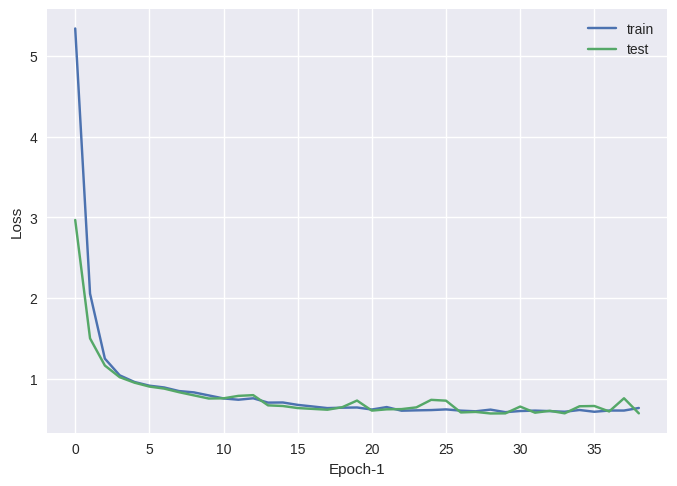

In [216]:
# Prepare and plot loss over time
plt.plot(train_loss,label="train")
plt.plot(test_loss,label="test")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")
plt.show()

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 737us/step
Correlation coefficient: 0.5229192367768264


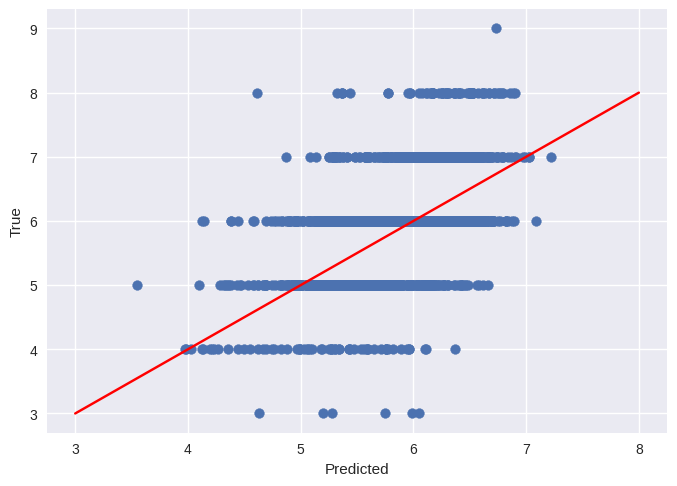

In [217]:
# After the training:

# Prepare scatter plot
y_pred = model.predict(X_test)[:,0]

print("Correlation coefficient:", np.corrcoef(y_pred,y_test)[0,1])
plt.scatter(y_pred,y_test)
plt.plot([3, 8], [3, 8], "red")  # add a dashed line for reference
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In this first run using the network of exercise 4.1 with adam optimizer, we obtain a correlation of 0.52. It is similar (even a bit worse) to the one we got in that exercise. We will try to improve the result by adding some complexity to the network.

In [218]:
model = Sequential()
# 11 inputs, 20 outputs, relu
model.add(layers.Input(shape=(11,))) 

# We add 5 layers and some regularization
for i in range(5):
    model.add(Dense(20, activation='relu',
            kernel_regularizer=keras.regularizers.l2(0.001)),
            layers.Dropout(0.2))

# 30 inputs (automatically detected by Keras), 1 output, linear activation
model.add(Dense(1, activation='linear'))

# Set loss function and optimiser algorithm
model.compile(
    loss='mse',  # mean squared error
    optimizer='adam' # adam optimizer
)

In [219]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=40, batch_size=32)


Epoch 1/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 16.5581 - val_loss: 3.4277
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.8269 - val_loss: 1.9086
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.0047 - val_loss: 0.6688
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7079 - val_loss: 0.7836
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6848 - val_loss: 0.6358
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6694 - val_loss: 0.6226
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6797 - val_loss: 0.6419
Epoch 8/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6878 - val_loss: 0.6838
Epoch 9/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6595 - val_loss: 0.6256
Epoch 10/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6569 - val_loss: 0.6356
Epoch 11/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6748 - val_loss: 0.8079
Epoch 12/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6558 - val_l

In [220]:
# The history object returned by the model training above
# contains the values of the loss function (the mean-squared-error)
# at different epochs
# We discard the first epoch as the loss value is very high,
# obscuring the rest of the distribution
train_loss = history.history["loss"][1:]
test_loss = history.history["val_loss"][1:]

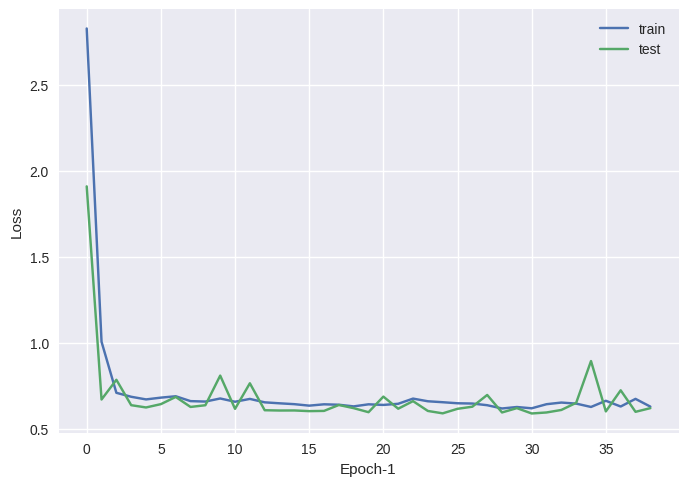

In [221]:
# Prepare and plot loss over time
plt.plot(train_loss,label="train")
plt.plot(test_loss,label="test")
plt.legend()
plt.xlabel("Epoch-1")
plt.ylabel("Loss")
plt.show()

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step
Correlation coefficient: 0.5380246108643183


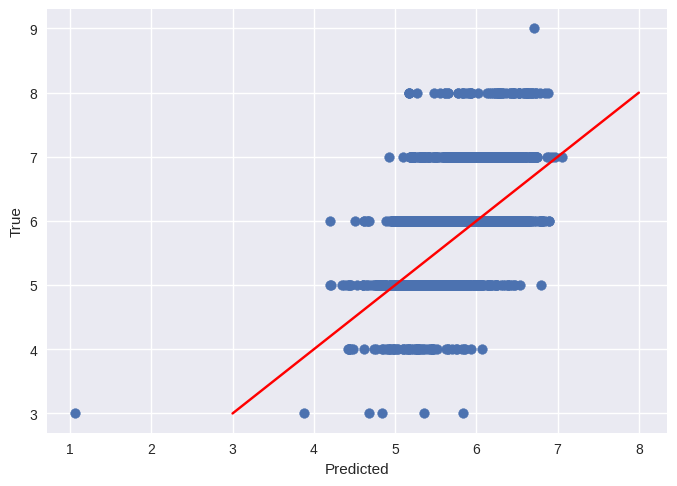

In [222]:
# After the training:

# Prepare scatter plot
y_pred = model.predict(X_test)[:,0]

print("Correlation coefficient:", np.corrcoef(y_pred,y_test)[0,1])
plt.scatter(y_pred,y_test)
plt.plot([3, 8], [3, 8], "red")  # add a dashed line for reference
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In this case, we are training a model with 5 layers of 20 neurons. We have added L2 regularization and some dropout to avoid overfitting in this deeper network. However, the correlation does not improve much with respect to the simple neural network. At least, we can see that the regularization is working, since the generalization error is negligible.

I have tried some more configurations, but I have not found any layout that gave good results. I think there is a limitation in the data. Wine quality may not be possible to predict in a reliable way based on the chemical properties.


# Problems

* Use the notebook as starting point. It already contains the simple network from Exercise 4.1 implemented in Keras.

* Currently, SGD is used without momentum. Try training with a momentum term. Replace SGD with the Adam optimizer and train using that. (See: https://keras.io/api/optimizers/)
* Add two more hidden layers to the network (you can choose the number of nodes but make sure to apply the ReLu activation function after each) and train again.
* Test differet numbers of examples (i.e. change the batch batch size) to be simulataneously used by the network.
* (bonus) optimize the network architecture to get the best correlation coefficient. (Let's see who gets the most out of the data).